In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Global plot styling (run once)
# =========================
import matplotlib as mpl

# Matplotlib global defaults
mpl.rcParams.update({
    "figure.dpi": 150,          # crisp in notebook
    "savefig.dpi": 300,         # crisp when saving for paper
    "font.size": 16,            # base font
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 12,
    "legend.title_fontsize": 8,
})

# Seaborn global defaults (affects all sns plots)
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.2)   # increase to 1.3–1.5 if still small

# Consistent figure size you already use, but centralized
DEFAULT_FIGSIZE = (12, 6)

# Shorter model labels (use these everywhere)
MODEL_LABELS = {
    "gpt-3.5-turbo": "GPT-3.5",
    "gpt-4-turbo": "GPT-4",
    "allam-2-7b": "Allam-2",
    "llama-3.3-70b-versatile": "LLaMA-3.3",
    "deepseek-r1-distill-llama-70b": "DeepSeek-R1",
}

# Optional: fixed order for x-axis
MODEL_ORDER = ["GPT-3.5", "GPT-4", "Allam-2-7B", "LLaMA-3.3-70B", "DeepSeek-R1\n(Distill LLaMA-70B)"]

def apply_short_model_labels(df, col="model"):
    """Replace long internal model IDs with short display labels."""
    if col in df.columns:
        df[col] = df[col].replace(MODEL_LABELS)
    return df


In [7]:
# Define file paths
file_paths = {
    "gpt-3.5-turbo": "/Users/dilanka/Documents/MSC Docs/reasoning evaluation/data/gpt-3.5-turbo.csv",
    "gpt-4-turbo": "/Users/dilanka/Documents/MSC Docs/reasoning evaluation/data/gpt-4-turbo.csv",
    "allam-2-7b": "/Users/dilanka/Documents/MSC Docs/reasoning evaluation/data/allam-2-7b.csv",
    "llama-3.3-70b-versatile": "/Users/dilanka/Documents/MSC Docs/reasoning evaluation/data/llama-3.3-70b-versatile.csv",
    "deepseek-r1-distill-llama-70b": "/Users/dilanka/Documents/MSC Docs/reasoning evaluation/data/deepseek-r1-distill-llama-70b.csv"
}

# Load the data
evaluation_data = {}
for model, path in file_paths.items():
    evaluation_data[model] = pd.read_csv(path)

# Preview a sample dataset
for model, df in evaluation_data.items():
    print(f"📌 Sample Data from {model}:\n", df.head(), "\n")
    break  # Print only one model's data for preview

📌 Sample Data from gpt-3.5-turbo:
    index                                               text  \
0      0  in the end we all die, nothing we do means any...   
1      1  Today would have been my best friend's 18th bi...   
2      2  So I couldn't feel any worse, and I've had eno...   
3      3  I am 22 and have never had a girlfriend and ha...   
4      4  I am almost certain that my depression is caus...   

                                     original_reason  \
0  feel more and more empty,fear lonliness,get ti...   
1   best friend's birthday, he's gone, never supp...   
2  absolute minimal contact with,  be more direct...   
3   never had a girlfriend, rejected countless times   
4  eating out with family, what after that? Paren...   

                                    generated_reason  original_reason_score  \
0  The person seems to be experiencing alienation...                     85   
1  The emotional distress, grief, and longing exp...                     90   
2  The perso

In [9]:
MODEL_LABELS = {
    "gpt-3.5-turbo": "GPT-3.5",
    "gpt-4-turbo": "GPT-4",
    "allam-2-7b": "Allam-2",
    "llama-3.3-70b-versatile": "LLaMA-3.3",
    "deepseek-r1-distill-llama-70b": "DeepSeek-R1",
}
evaluation_data = {
    MODEL_LABELS.get(model, model): df
    for model, df in evaluation_data.items()
}


In [10]:
evaluation_data.keys()
# dict_keys(['GPT-3.5', 'GPT-4', 'Allam-2', 'LLaMA-3.3', 'DeepSeek-R1'])


dict_keys(['GPT-3.5', 'GPT-4', 'Allam-2', 'LLaMA-3.3', 'DeepSeek-R1'])

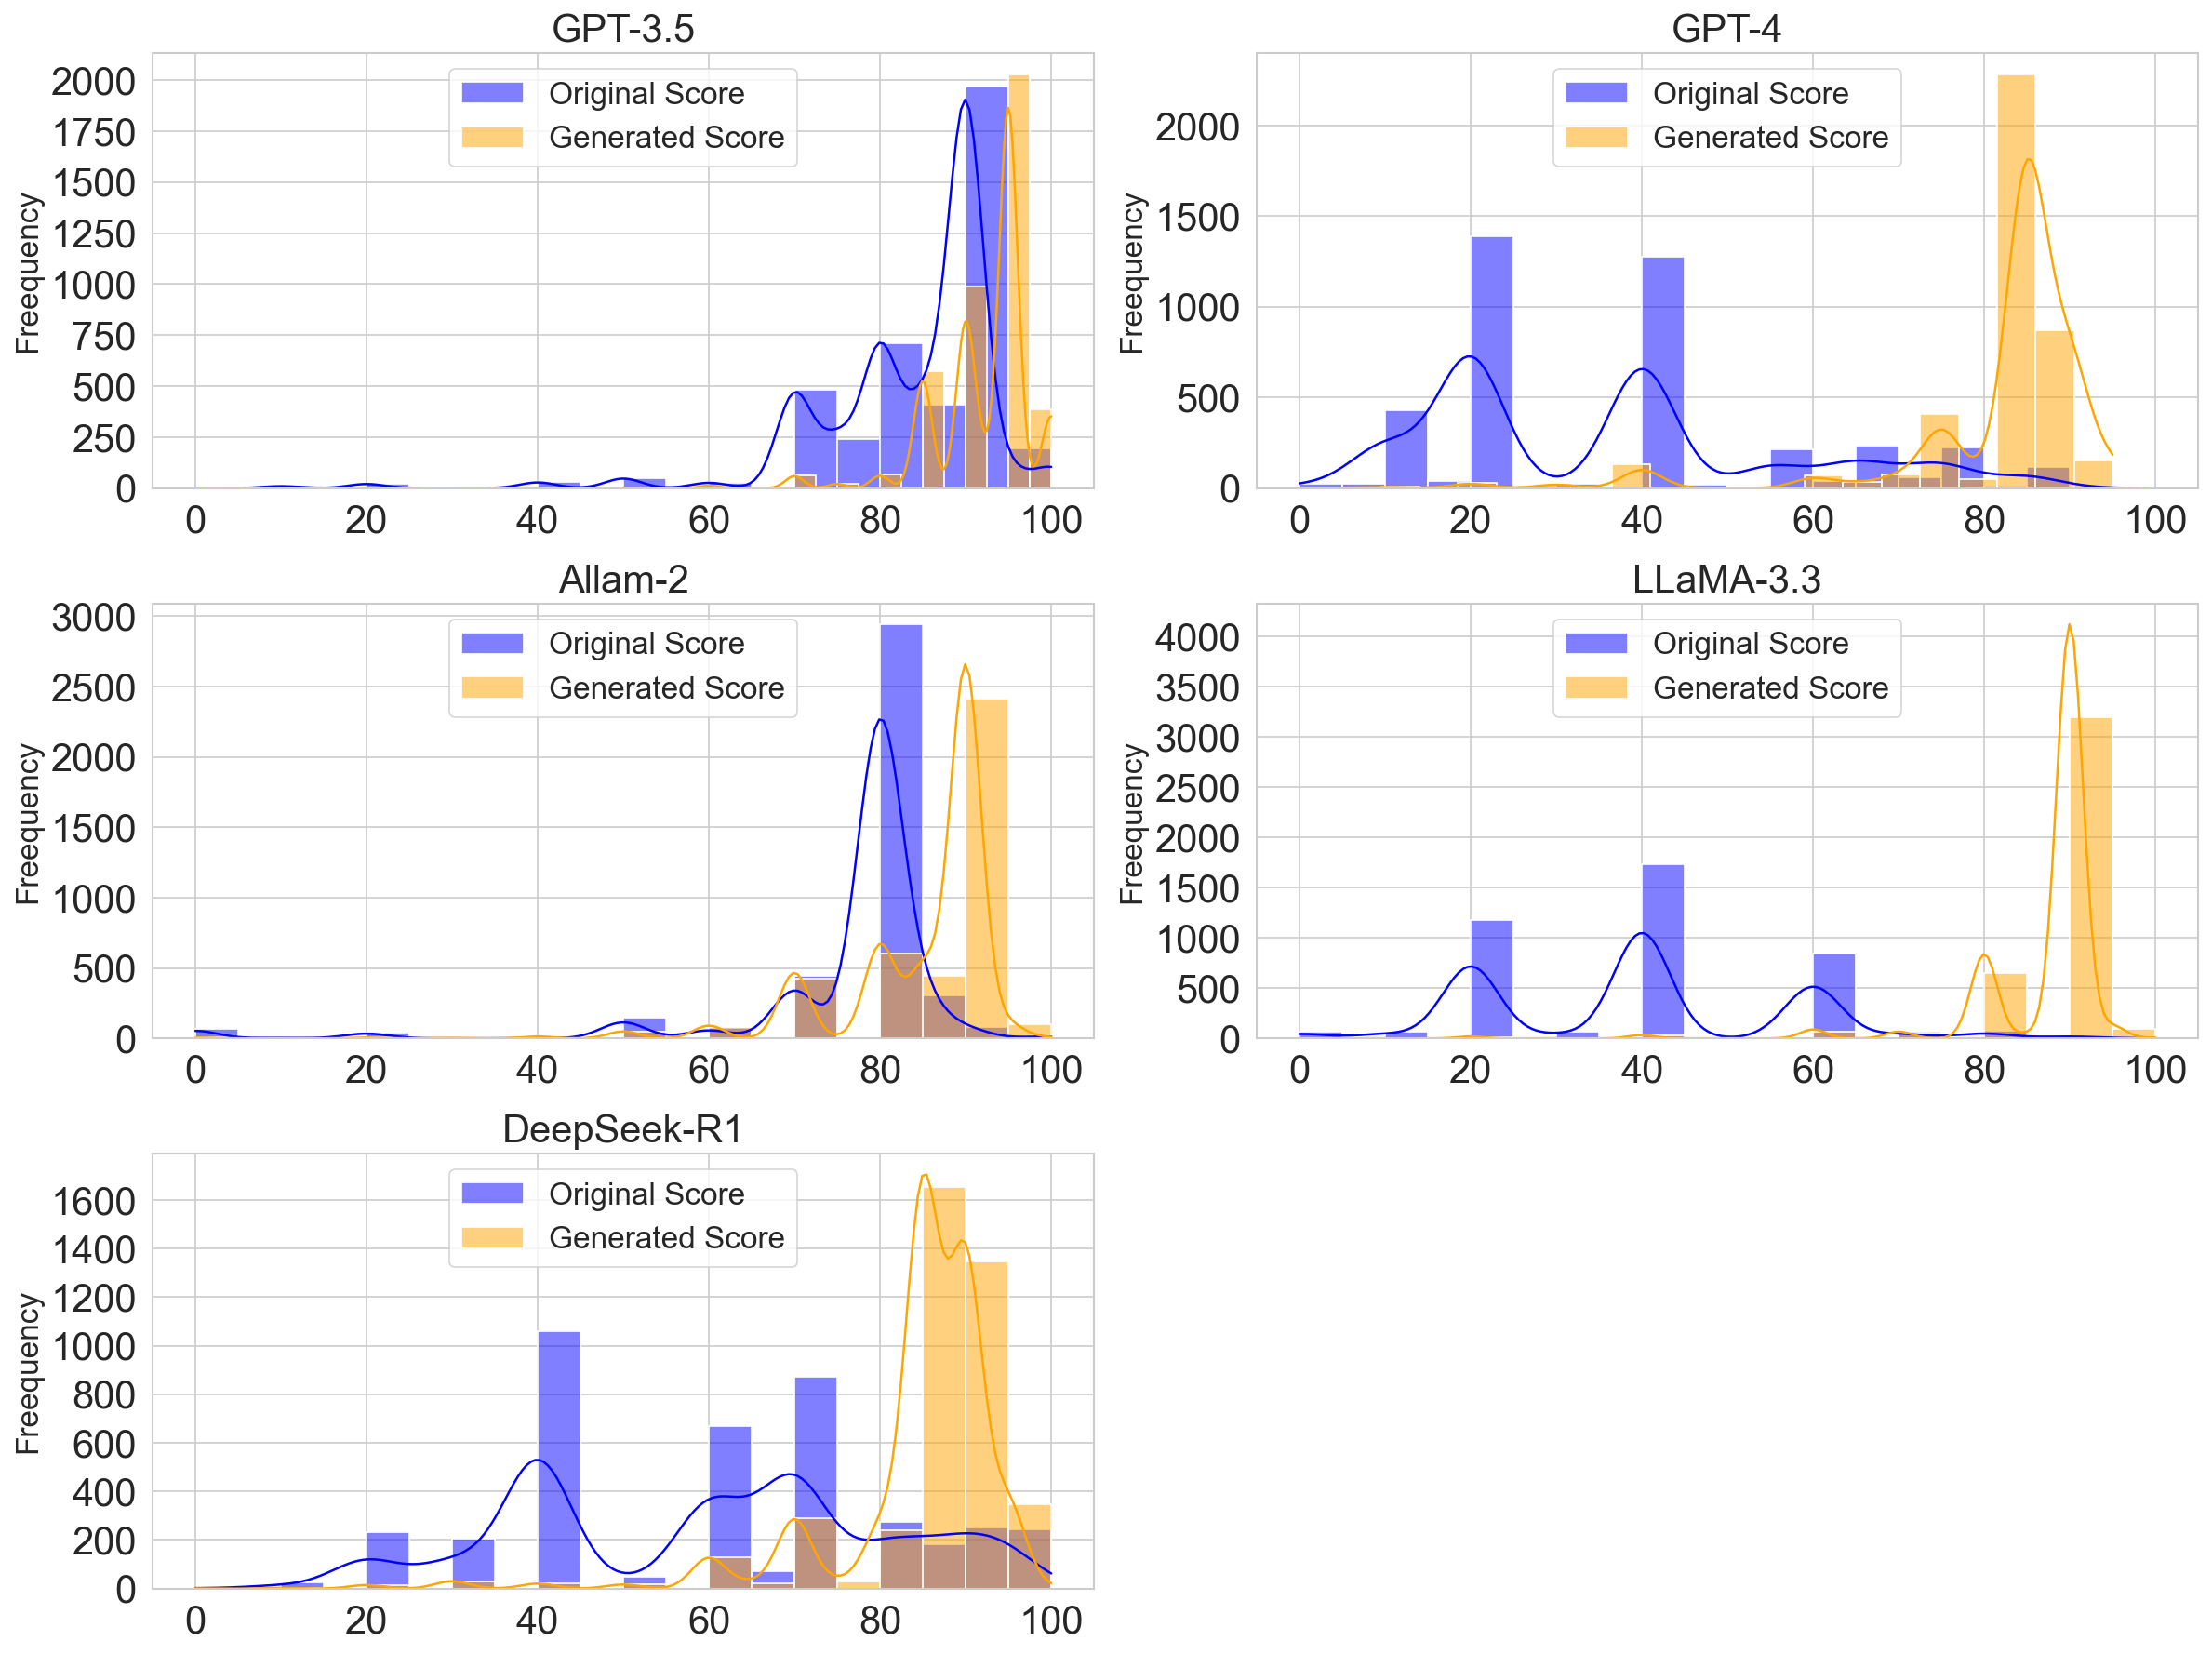

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define figure size
plt.figure(figsize=(16, 12))

# Loop through each model and create individual histograms
for i, (model, df) in enumerate(evaluation_data.items(), 1):
    plt.subplot(3, 2, i)  # Create a 3-row, 2-column subplot layout
    sns.histplot(df["original_reason_score"], kde=True, label="Original Score", bins=20, alpha=0.5, color="blue")
    sns.histplot(df["generated_reason_score"], kde=True, label="Generated Score", bins=20, alpha=0.5, color="orange")
    
    plt.ylabel("Freequency", fontsize=16)
    plt.xlabel(None)
    plt.title(f"{model}", fontsize=20)
    plt.yticks(fontsize=20)
    plt.xticks(fontsize=20)
    plt.legend(title=None, loc="upper center", fontsize=16)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()


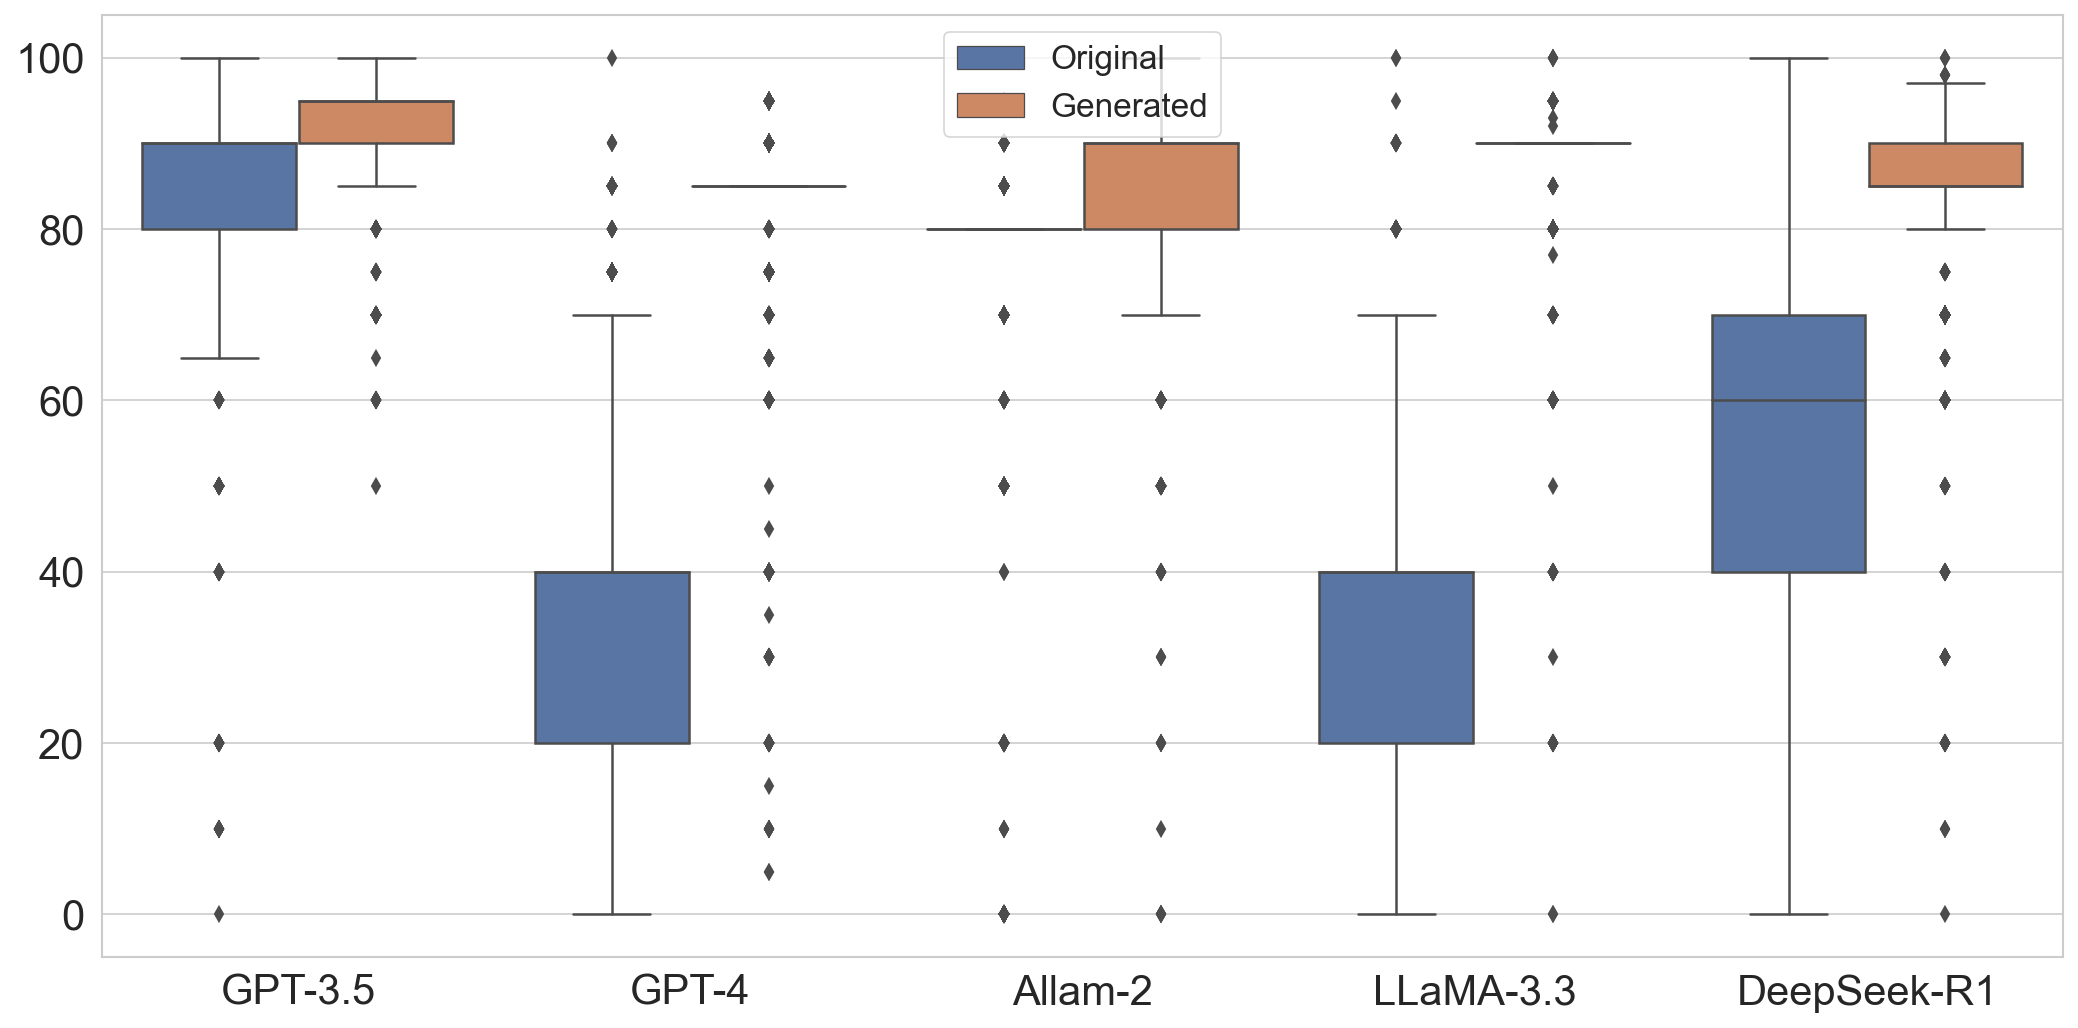

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Build long-form dataframe
rows = []
for model, df in evaluation_data.items():
    rows.append(
        pd.DataFrame({
            "Model": model,
            "Score": df["original_reason_score"],
            "Type": "Original"
        })
    )
    rows.append(
        pd.DataFrame({
            "Model": model,
            "Score": df["generated_reason_score"],
            "Type": "Generated"
        })
    )

boxplot_df = pd.concat(rows, ignore_index=True)
plt.figure(figsize=(14, 7))

ax = sns.boxplot(
    data=boxplot_df,
    x="Model",
    y="Score",
    hue="Type",
    palette={
        "Original": "#4C72B0",   # blue
        "Generated": "#DD8452"   # orange
    }
)

# Formatting
ax.set_xlabel("")                 # remove x-axis label
ax.set_ylabel("")

ax.tick_params(axis="x", labelsize=20, rotation=0)
ax.tick_params(axis="y", labelsize=20)

# Legend (only two entries)
ax.legend(
    title=None,
    fontsize=16,
    loc="upper center",
)

plt.tight_layout()
plt.show()


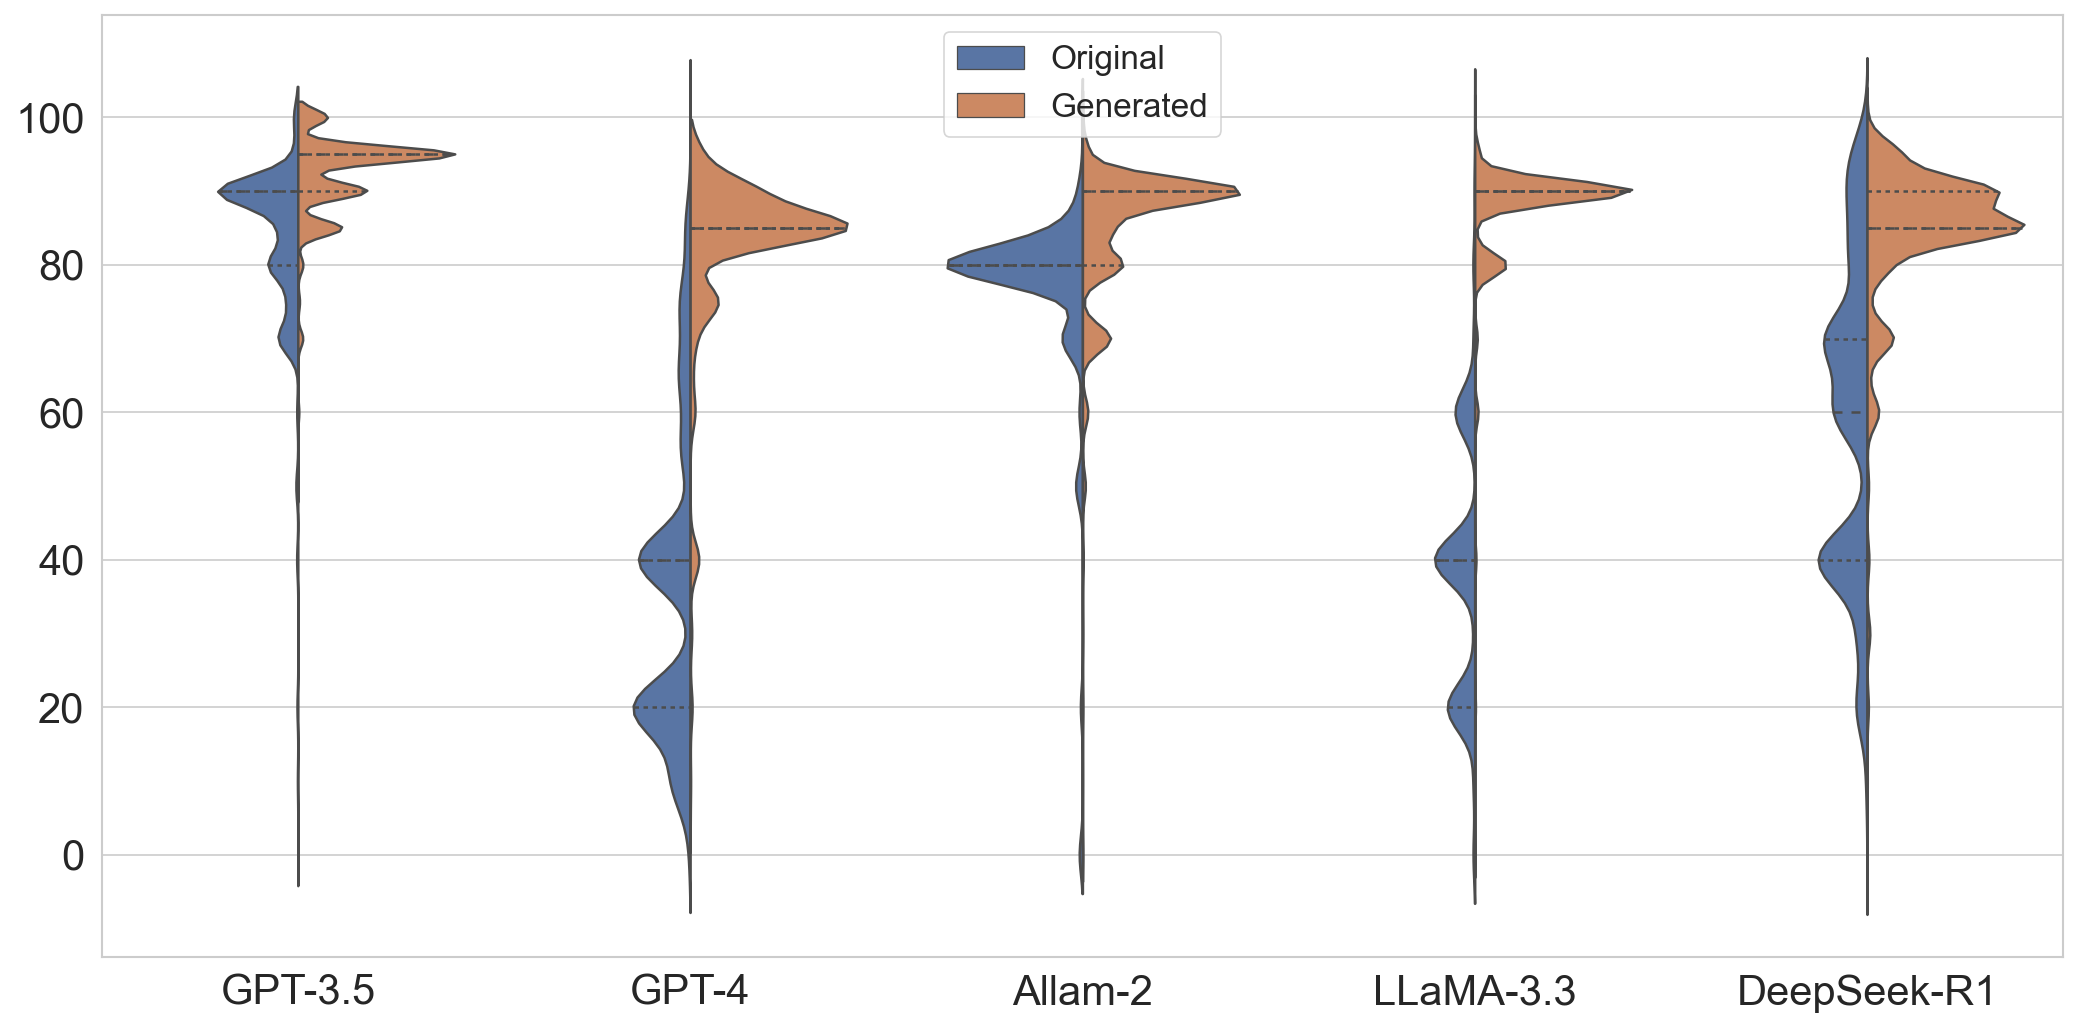

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

rows = []
for model, df in evaluation_data.items():
    rows.append(
        pd.DataFrame({
            "Model": model,
            "Score": df["original_reason_score"],
            "Type": "Original"
        })
    )
    rows.append(
        pd.DataFrame({
            "Model": model,
            "Score": df["generated_reason_score"],
            "Type": "Generated"
        })
    )

violin_df = pd.concat(rows, ignore_index=True)
plt.figure(figsize=(14, 7))

ax = sns.violinplot(
    data=violin_df,
    x="Model",
    y="Score",
    hue="Type",
    split=True,                 # Original vs Generated in one violin
    inner="quartile",
    palette={
        "Original": "#4C72B0",   # blue
        "Generated": "#DD8452"   # orange
    }
)

# Formatting
ax.set_xlabel("")                       # remove x-axis label
ax.set_ylabel("", fontsize=16)

ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)

# Legend (only two entries)
ax.legend(
    title=None,
    fontsize=16,
    loc="upper center",
)

plt.tight_layout()
plt.show()


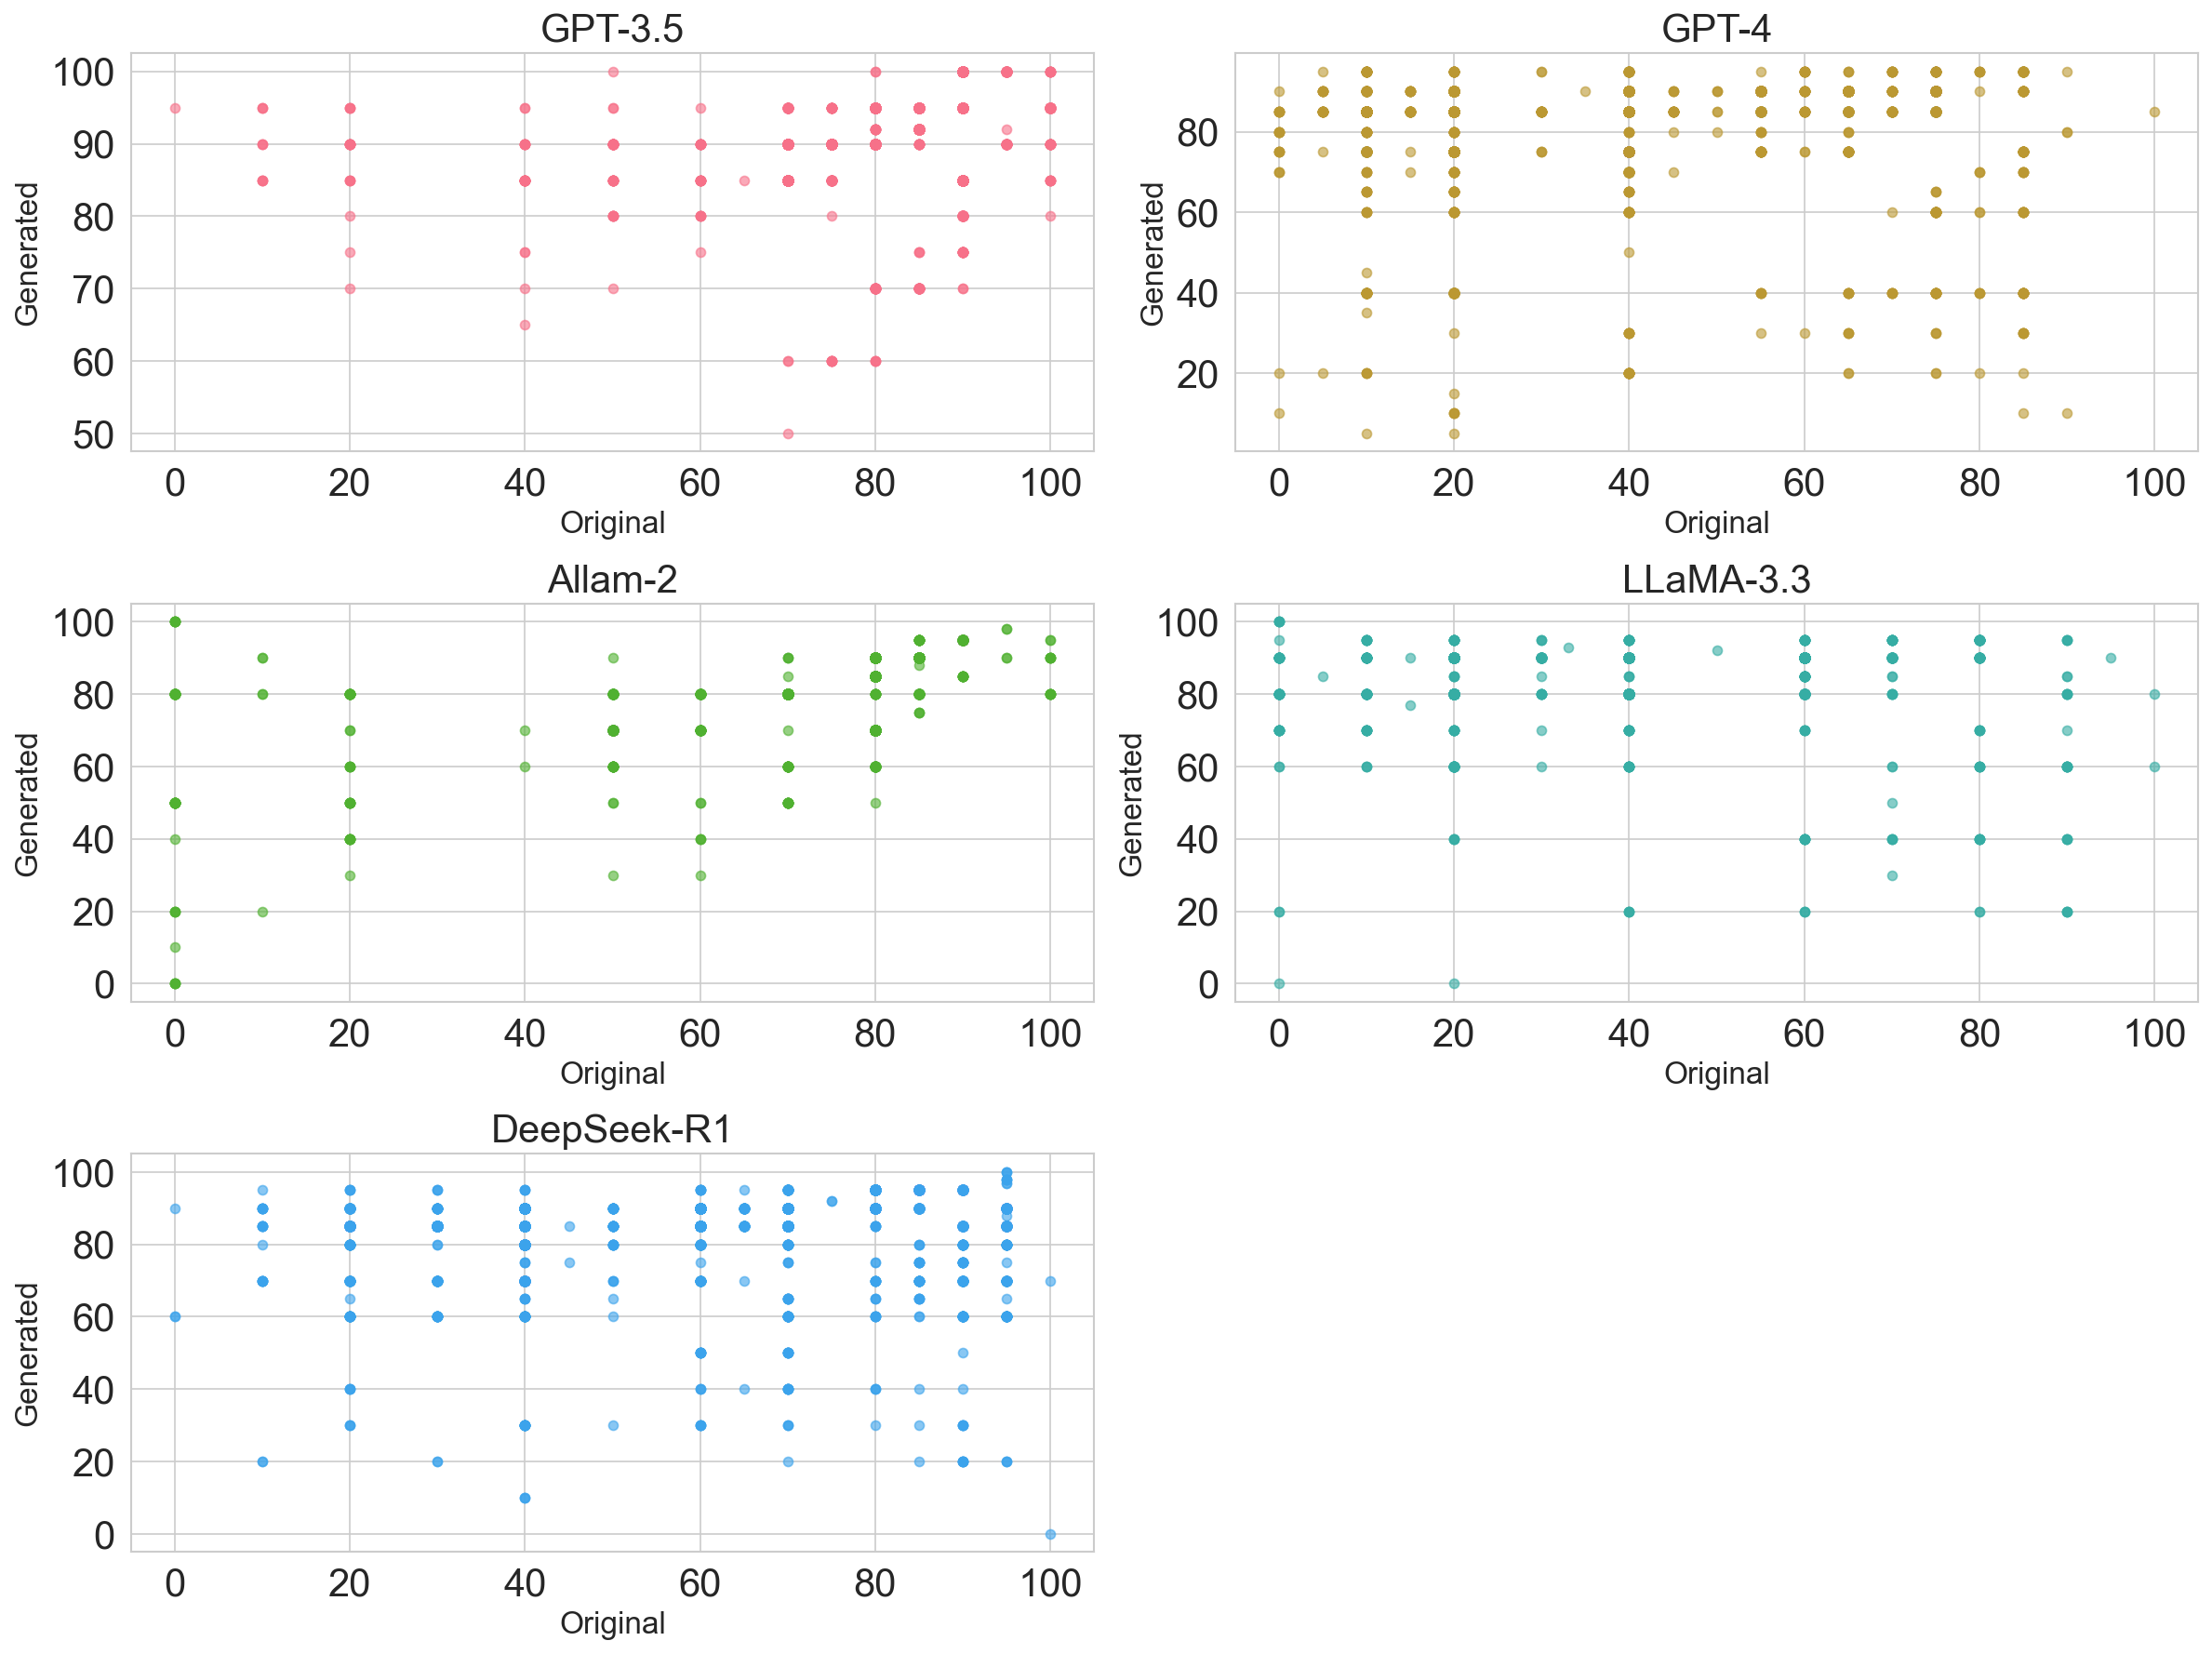

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define figure size
plt.figure(figsize=(16, 12))

# Loop through each model and create individual scatter plots
for i, (model, df) in enumerate(evaluation_data.items(), 1):
    plt.subplot(3, 2, i)  # Create a 3-row, 2-column subplot layout
    plt.scatter(df["original_reason_score"], df["generated_reason_score"], alpha=0.6, color=sns.color_palette("husl")[i-1])
    
    plt.xlabel("Original", fontsize=16)
    plt.ylabel("Generated", fontsize=16)
    plt.yticks(fontsize=20)
    plt.xticks(fontsize=20)
    plt.title(f"{model}", fontsize=20)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

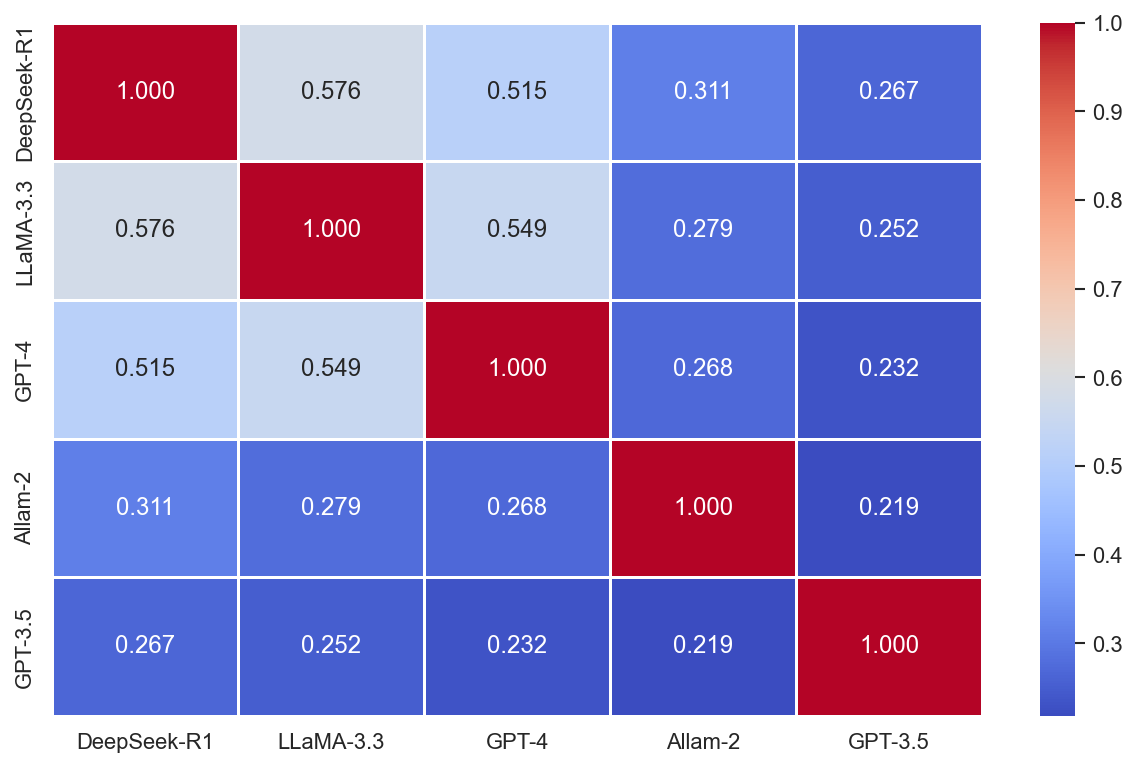

In [48]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

score_diffs = {model: evaluation_data[model]["generated_reason_score"] - evaluation_data[model]["original_reason_score"]
               for model in evaluation_data}

diff_df = pd.DataFrame(score_diffs)

# Compute correlation matrix
corr_matrix = diff_df.corr()

# Sort by correlation strength
sorted_models = corr_matrix.mean().sort_values(ascending=False).index
corr_matrix = corr_matrix.loc[sorted_models, sorted_models]

# Heatmap with better formatting
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".3f", linewidths=0.5)
plt.show()


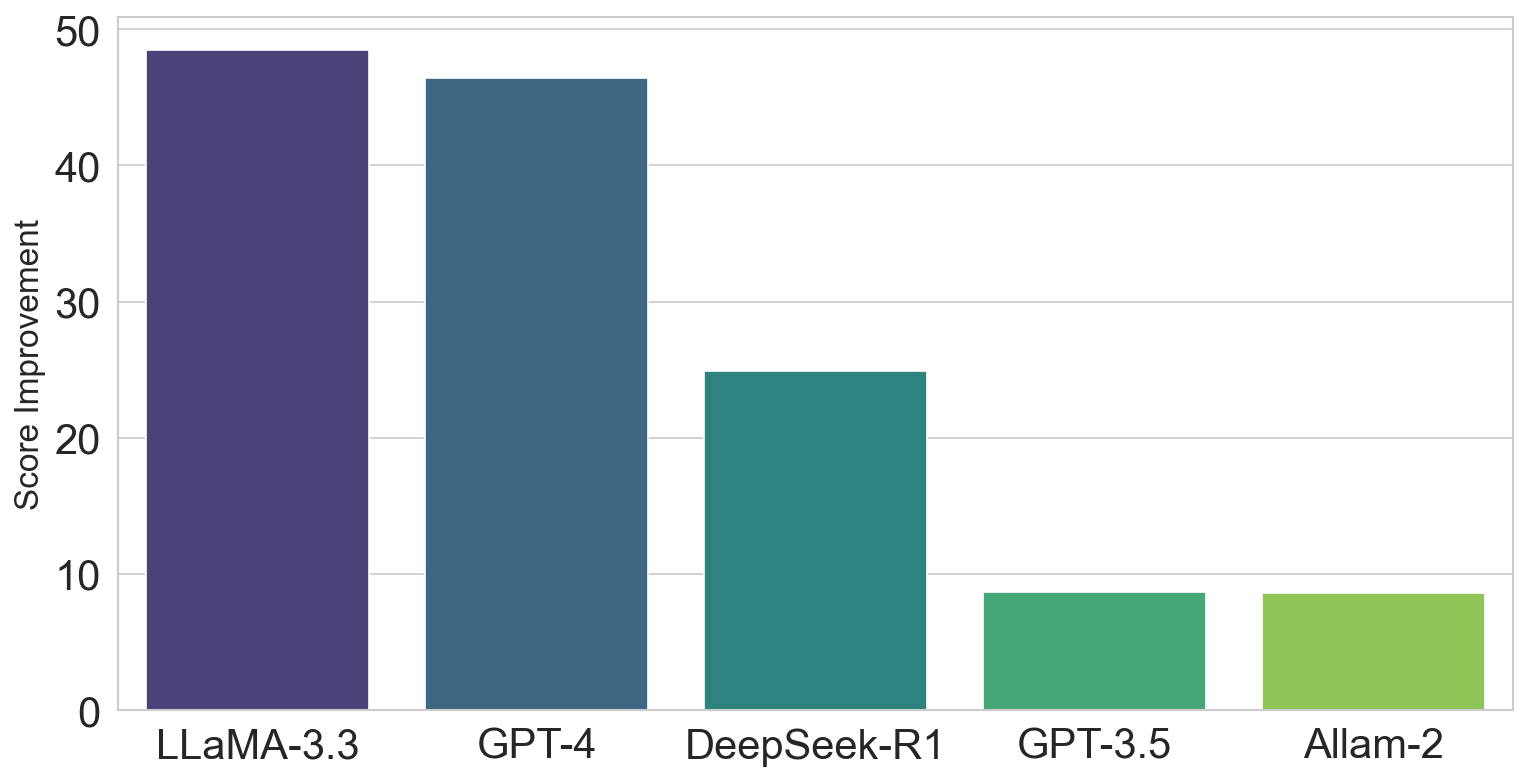

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate model performance improvement
performance_data = {"Model": [], "Improvement": [], "Percentage Improvement": []}

for model, df in evaluation_data.items():
    avg_original = df["original_reason_score"].mean()
    avg_generated = df["generated_reason_score"].mean()
    improvement = avg_generated - avg_original
    percentage_improvement = ((avg_generated - avg_original) / avg_original) * 100  # Percentage improvement calculation

    performance_data["Model"].append(model)
    performance_data["Improvement"].append(improvement)
    performance_data["Percentage Improvement"].append(percentage_improvement)

performance_df = pd.DataFrame(performance_data)

# Sort data by improvement
performance_df = performance_df.sort_values(by="Improvement", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="Improvement", data=performance_df, palette="viridis")
plt.ylabel('Score Improvement', fontsize=16)
plt.xlabel(None)
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)
plt.show()


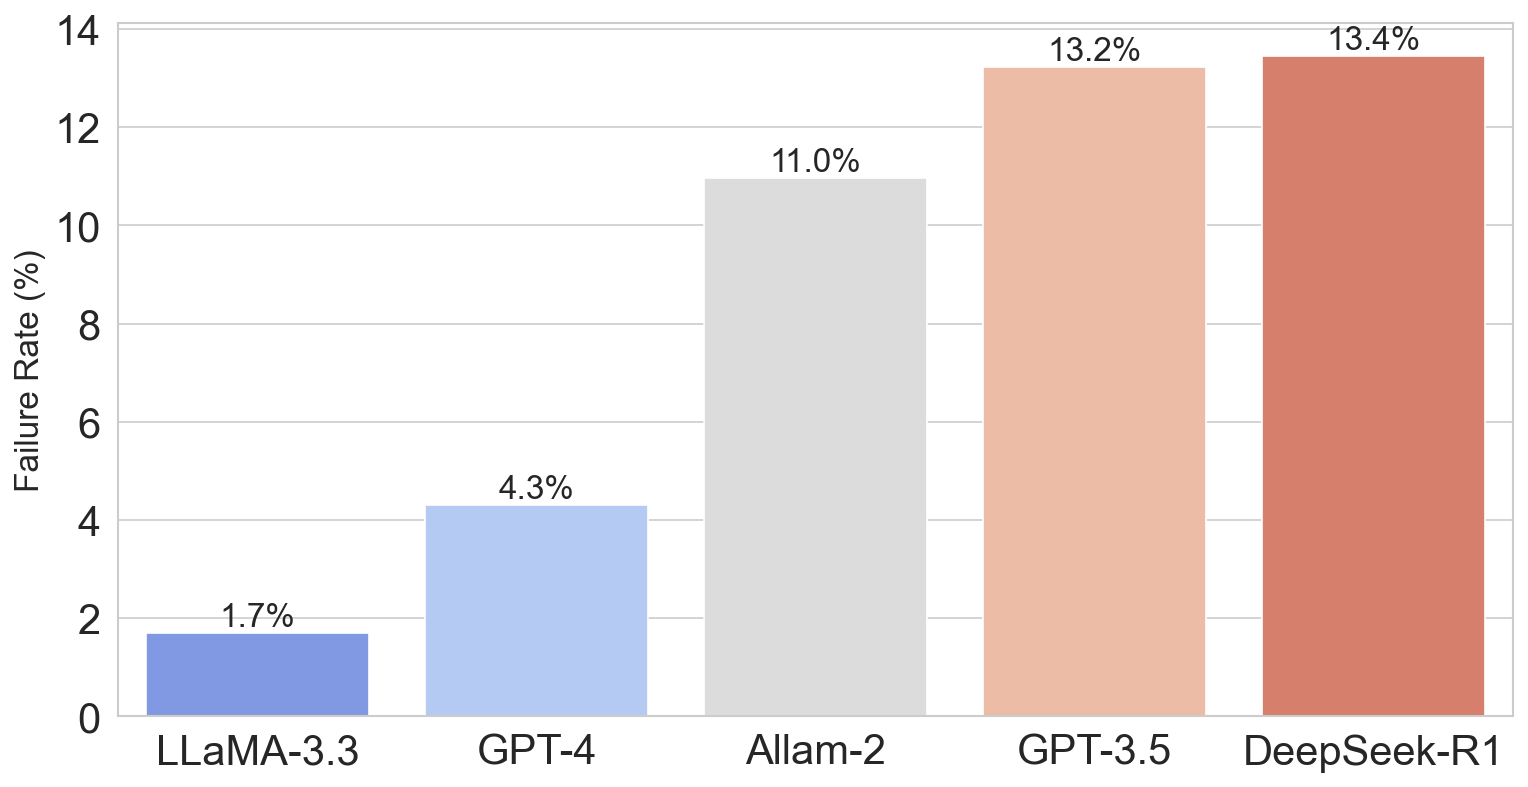

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Compute failure rates
failure_rates = []
for model, df in evaluation_data.items():
    failure_rate = (df["generated_reason_score"] < df["original_reason_score"]).sum() / len(df) * 100
    failure_rates.append([model, failure_rate])

# Convert to DataFrame
failure_df = pd.DataFrame(failure_rates, columns=["Model", "Failure Rate"])

# Sort models by failure rate
failure_df = failure_df.sort_values(by="Failure Rate", ascending=True)

# Create bar chart
ax = sns.barplot(x="Model", y="Failure Rate", data=failure_df, palette="coolwarm")
plt.ylabel("Failure Rate (%)", fontsize=16)

# Add percentage labels
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=16)

plt.xlabel(None)
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)
plt.show()

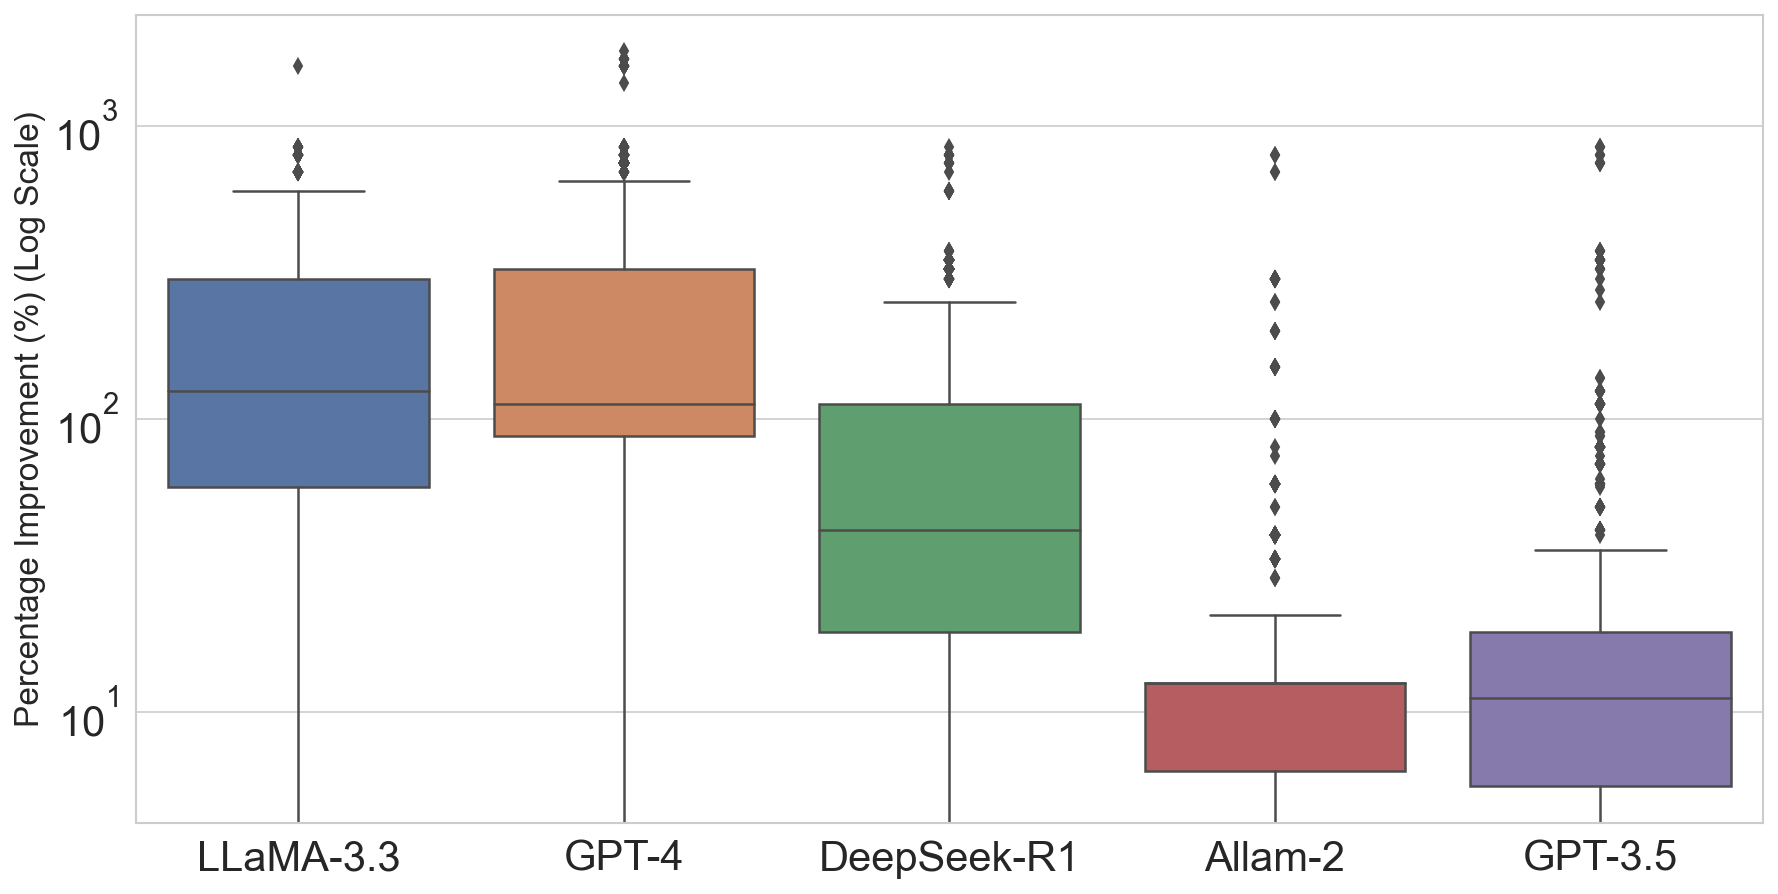

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 7))

percentage_improvements = []
labels = []

for model, df in evaluation_data.items():
    improvement = ((df["generated_reason_score"] - df["original_reason_score"]) / df["original_reason_score"]) * 100
    percentage_improvements.append(improvement)
    labels.append(model)

# Convert to DataFrame
improvement_df = pd.DataFrame(percentage_improvements).T
improvement_df.columns = labels

# Sort by median improvement
sorted_models = improvement_df.median().sort_values(ascending=False).index
improvement_df = improvement_df[sorted_models]

# Create the boxplot with log scale
sns.boxplot(data=improvement_df)
plt.yscale("log")  # Use logarithmic scale for better visualization
plt.xlabel(None)
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)
plt.ylabel("Percentage Improvement (%) (Log Scale)", fontsize=16 )
plt.show()
